In [1]:
import os
import gc
import zarr
import yaml
import json
import numba
import numpy as np
import polars as pl
import pandas as pd
from tqdm import tqdm
import statsmodels.api as sm
from scipy import stats

from plotnine import *
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

In [2]:
# Configuration and paths
mac = 20
pheno_list_type = None
# pheno_list_type = 'biochemistry'
# pheno_list_type = 'overall_phenotype'

new_anno_df_path = None

# Load phenotype configuration
pheno_config_path = "/home/dnanexus/ukbgym/phenotype_config.yaml"
with open(pheno_config_path) as f:
    pheno_config = yaml.safe_load(f)

if pheno_list_type is not None:
    pheno_list = pheno_config[pheno_list_type]

eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'

# Load annotation configuration
config_path = "/home/dnanexus/ukbgym/config_odds_categories.yaml"
with open(config_path) as f:
    config = yaml.safe_load(f)

records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records).with_columns(
    pl.col("annotation_dir").cast(pl.Int8)
)

all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()

anno_config_df

category,annotation,color,label,annotation_dir
str,str,str,str,i8
"""genomic_region""","""mane_cds""","""#E31A1C""","""MANE CDS""",1
"""genomic_region""","""non_mane_cds""","""#FB9A99""","""Other CDS""",1
"""genomic_region""","""mane_exonic""","""#33A02C""","""MANE Exon""",1
"""genomic_region""","""non_mane_exonic""","""#B2DF8A""","""Other Exon""",1
"""plof_consequences""","""consequence_frameshift_variant""","""#E31A1C""","""VEP Frameshift""",1
…,…,…,…,…
"""encode_enhancer""","""encode_ca_ctcf""","""#4DAF4A""","""Accessible Region with CTCF Bi…",1
"""encode_enhancer""","""encode_ca""","""#377EB8""","""Chromatin Accessible""",1
"""encode_enhancer""","""encode_ca_tf""","""#1D6498""","""Accessible Region with TF Bind…",1


In [3]:
!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/wgs/qced_maf1e-3_loftee_olink_genes/qced_maf1e-3_loftee_olink_genes_EURunrelated/annotations_fillna_ukbgym.parquet -o /home/dnanexus/data_dir/annotations_fillna_ukbgym.parquet

anno = pl.scan_parquet("/home/dnanexus/data_dir/annotations_fillna_ukbgym.parquet")

min_range = -2000
max_range = +0

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]

anno = (
    anno
    .filter(
        # Choose CDS
        (pl.col('vep_cds_relaxed')==True)
        # ((pl.col('vep_cds') == True) | (pl.col('mane_cds') == True) | (pl.col('non_mane_cds') == True)) &

        # Only SNPs
        # (pl.col('ref').str.len_chars()==1) & (pl.col('alt').str.len_chars()==1)
    )
    .select(
        set(['id', 'region', 'gene_name'])
        .union(set(existing_annos))
        # .union(set(plof_cols))
    )
    .with_columns(
        start_stop_lost = (pl.col('consequence_start_lost') == 1) | (pl.col('consequence_stop_lost') == 1)
    )
    .collect(engine='streaming')
)

anno

Error: path "/home/dnanexus/data_dir/annotations_fillna_ukbgym.parquet"
already exists but -f/--overwrite was not set


low_complexity_domain,consequence_splice_donor_variant,loftee_hc,consequence_start_lost,consequence_frameshift_variant,five_prime_utr_variant_consequence_uaug_gained,mobi_lip_full,loftee_lc,gene_name,consequence_stop_lost,consequence_stop_gained,consequence_splice_acceptor_variant,region,consequence_missense_variant,five_prime_utr_variant_consequence_ustop_lost,five_prime_utr_variant_consequence_ustop_gained,ted_domain,five_prime_utr_variant_consequence_uaug_lost,id,mobi_curated_disorder_priority,five_prime_utr_variant_consequence_uframeshift,start_stop_lost
bool,i8,i8,i8,i8,u8,bool,i8,str,i8,i8,i8,str,i8,u8,u8,bool,u8,str,bool,u8,bool
false,0,0,0,0,0,false,0,"""RASA1""",0,0,0,"""ENSG00000145715""",1,0,0,false,0,"""chr5:87376465:A:T""",false,0,false
false,0,1,0,0,0,true,0,"""SEC16B""",0,1,0,"""ENSG00000120341""",0,0,0,false,0,"""chr1:177933615:G:A""",false,0,false
false,0,0,0,0,0,false,0,"""CNNM3""",0,0,0,"""ENSG00000168763""",0,0,0,false,0,"""chr2:96816550:C:T""",false,0,false
false,0,0,0,0,0,true,0,"""TTN""",0,0,0,"""ENSG00000155657""",1,0,0,false,0,"""chr2:178598858:G:A""",false,0,false
false,0,0,0,0,0,false,0,"""HS6ST1""",0,0,0,"""ENSG00000136720""",1,0,0,true,0,"""chr2:128318064:C:T""",false,0,false
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
false,0,1,0,0,0,false,0,"""CD38""",0,1,0,"""ENSG00000004468""",0,0,0,true,0,"""chr4:15816634:C:A""",false,0,false
true,0,0,0,0,0,false,0,"""TBC1D2B""",0,0,0,"""ENSG00000167202""",0,0,0,false,0,"""chr15:78077599:C:A""",false,0,false
false,0,0,0,0,0,true,0,"""ZFYVE26""",0,0,0,"""ENSG00000072121""",0,0,0,true,0,"""chr14:67783209:G:A""",false,0,false


In [4]:
# selected_annos = anno_config_df.filter(
#     pl.col('category').is_in(['plof_consequences']) # plof consequences
# )['annotation'].to_list()

selected_annos = ['consequence_stop_lost', 'consequence_start_lost', 'consequence_splice_donor_variant', 'loftee_hc', 'consequence_splice_acceptor_variant', 'loftee_lc', 'consequence_stop_gained', 'consequence_frameshift_variant', 'consequence_missense_variant']

melted_anno = (
    anno

    .select(
        set(['id', 'region']).union(set(selected_annos))
    )

    .unpivot(
        index=["id", "region"],
        on=selected_annos,
        variable_name="annotation",
        value_name="annotation_score"
    )
    .with_columns(
        pl.col("annotation_score").cast(pl.Float32),
        pl.col("region").cast(pl.Utf8),
    )

    # Merge with annotation configuration to get direction and filter
    .join(
        anno_config_df.select(["annotation", "category", "annotation_dir"]),
        on="annotation",
        how="left"
    )
    .with_columns(
        # annotation_score_dircor = pl.col('annotation_score') * pl.col("annotation_dir")
        annotation_score_dircor = (
            pl.when(pl.col("annotation_dir")!=1)
            .then((pl.col('annotation_score')-1).abs())
            .otherwise(pl.col('annotation_score'))
        )
    )
    
    .filter(
        (pl.col('annotation_score') != 0)
    )
)

melted_anno

id,region,annotation,annotation_score,category,annotation_dir,annotation_score_dircor
str,str,str,f32,str,i8,f32
"""chr14:70030258:A:T""","""ENSG00000198732""","""consequence_stop_lost""",1.0,"""plof_consequences""",1,1.0
"""chr1:156659133:A:G""","""ENSG00000132692""","""consequence_stop_lost""",1.0,"""plof_consequences""",1,1.0
"""chr11:7665376:A:T""","""ENSG00000166394""","""consequence_stop_lost""",1.0,"""plof_consequences""",1,1.0
"""chr12:56229211:T:C""","""ENSG00000139579""","""consequence_stop_lost""",1.0,"""plof_consequences""",1,1.0
"""chr1:1211557:A:G""","""ENSG00000186827""","""consequence_stop_lost""",1.0,"""plof_consequences""",1,1.0
…,…,…,…,…,…,…
"""chr16:57439221:C:T""","""ENSG00000005194""","""consequence_missense_variant""",1.0,"""missense""",1,1.0
"""chr10:89725023:G:T""","""ENSG00000138182""","""consequence_missense_variant""",1.0,"""missense""",1,1.0
"""chr1:55046566:C:T""","""ENSG00000169174""","""consequence_missense_variant""",1.0,"""missense""",1,1.0


In [5]:
# Get gene trait associations
!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/REGENIE_results/regenie_127phenotypes_lofteeHC_mac20_EUR.parquet -o /home/dnanexus/data_dir/
# !dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/REGENIE_results/loftee_mac20_associations_bh_corrected.parquet -o /home/dnanexus/data_dir/

!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/REGENIE_results/regenie_127phenotypes_mac20_lofteeHC_EUR_correlations.parquet -o /home/dnanexus/data_dir/

gene_trait_df = (
    pl.read_parquet('/home/dnanexus/data_dir/regenie_127phenotypes_lofteeHC_mac20_EUR.parquet')
    .filter(pl.col('pval_fdr')<=0.05)
    .select(['region', 'phenotype', 'pval_fdr'])
)

loftee_corrs = (
    pl.read_parquet('/home/dnanexus/data_dir/regenie_127phenotypes_mac20_lofteeHC_EUR_correlations.parquet')
    .with_columns(
        loftee_corr = pl.col('correlation'),
        loftee_corr_abs = pl.col('correlation').abs(),
        loftee_corr_dir = pl.col('correlation')/pl.col('correlation').abs(),
    )
    .select(['region', 'phenotype', 'loftee_corr', 'loftee_corr_abs', 'loftee_corr_dir']) 
)

gene_trait_df = (
    gene_trait_df
    .join(loftee_corrs, on=['region', 'phenotype'], how='inner')
    .drop_nans()
    # .sort('loftee_corr_abs', descending=True)
    # .sort('pval_fdr')
    # .unique(subset=["region"], keep="first", maintain_order=True)
)
gene_trait_df

Error: path
"/home/dnanexus/data_dir/regenie_127phenotypes_lofteeHC_mac20_EUR.parquet"
already exists but -f/--overwrite was not set
Error: path "/home/dnanexus/data_dir/regenie_127phenotypes_mac20_lofteeHC_EUR_
correlations.parquet" already exists but -f/--overwrite was not set


region,phenotype,pval_fdr,loftee_corr,loftee_corr_abs,loftee_corr_dir
str,str,f64,f64,f64,f64
"""ENSG00000067900""","""lymphocyte_count_int""",0.015659,-0.097882,0.097882,-1.0
"""ENSG00000145386""","""mean_corpuscular_haemoglobin_i…",0.000096,-0.059845,0.059845,-1.0
"""ENSG00000164944""","""trunk_predicted_mass_int""",0.015511,-0.04623,0.04623,-1.0
"""ENSG00000107863""","""trunk_predicted_mass_int""",0.033889,-0.122605,0.122605,-1.0
"""ENSG00000121966""","""eosinophill_percentage_int""",0.000392,-0.075765,0.075765,-1.0
…,…,…,…,…,…
"""ENSG00000142208""","""arm_predicted_mass_right_int""",0.009537,-0.049973,0.049973,-1.0
"""ENSG00000101670""","""cholesterol_int""",0.000099,0.035791,0.035791,1.0
"""ENSG00000017427""","""weight_int""",0.000158,-0.170599,0.170599,-1.0


In [6]:
!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/avg_pheno_per_var/loftee_mac20_quant_pheno_assocs_EURunrelated_appv_percentiles.parquet -o /home/dnanexus/data_dir/loftee_mac20_quant_pheno_assocs_EURunrelated_appv_percentiles.parquet

appv = pl.scan_parquet("/home/dnanexus/data_dir/loftee_mac20_quant_pheno_assocs_EURunrelated_appv_percentiles.parquet")

# Create a lazy frame with the unique keys
anno_keys = anno.select(pl.col('id').unique()).lazy()

# Chain the filter and the much faster semi join
appv = (
    appv
    .join(
        anno_keys, on='id', how='semi'
    )
    .filter(
        pl.col('n_individuals') <= mac
    )
    .select(
        ['id', 'phenotype', 'mean_pheno_value', 'n_individuals']
    )
)
# unique_phenotypes = appv.select('phenotype').unique().collect(engine='streaming').to_series()

Error: path "/home/dnanexus/data_dir/loftee_mac20_quant_pheno_assocs_EURunrela
ted_appv_percentiles.parquet" already exists but -f/--overwrite was not set


In [7]:
plof_pheno_df = (
    # A. Use a semi join for efficient filtering (more memory-safe than 'is_in')
    appv
    # B. Join the other two dataframes
    .join(
        melted_anno.lazy(),
        on="id", 
        how="inner"
    )
    .join(
        gene_trait_df.lazy(), 
        on=["region", "phenotype"], 
        how="inner"
    )
    .with_columns(
        mean_pheno_value_dircor = pl.col('mean_pheno_value')*pl.col('loftee_corr_dir')
    )
    
    # C. Group by annotation and aggregate
    .group_by(['annotation'])
    .agg(
        n_vars = pl.col('id').n_unique(),
        median_pheno = pl.col('mean_pheno_value_dircor').median(),
        mean_pheno = pl.col('mean_pheno_value_dircor').mean(),
        std_pheno = pl.col('mean_pheno_value_dircor').std(),
    )
    .with_columns(
        se_pheno = pl.col('std_pheno') / pl.col('n_vars').sqrt()
    )
    .with_columns(
        ci_low_pheno = pl.col('mean_pheno') - 1.96*pl.col('se_pheno'),
        ci_high_pheno = pl.col('mean_pheno') + 1.96*pl.col('se_pheno'),
    )
    .collect(engine='streaming')
)

plof_pheno_df

annotation,n_vars,median_pheno,mean_pheno,std_pheno,se_pheno,ci_low_pheno,ci_high_pheno
str,u64,f64,f64,f64,f64,f64,f64
"""consequence_start_lost""",645,0.238018,0.276359,0.788989,0.031066,0.215469,0.337249
"""consequence_stop_gained""",12319,0.302349,0.327701,0.762123,0.006867,0.314243,0.34116
"""consequence_missense_variant""",352994,0.033539,0.049253,0.641259,0.001079,0.047137,0.051368
"""consequence_frameshift_variant""",18788,0.308153,0.326373,0.794889,0.005799,0.315007,0.337739
"""consequence_stop_lost""",209,0.114186,0.152474,0.741184,0.051269,0.051987,0.252961
"""loftee_hc""",37677,0.302409,0.323675,0.765763,0.003945,0.315943,0.331408
"""consequence_splice_donor_varia…",4578,0.278456,0.294114,0.713241,0.010541,0.273452,0.314775
"""loftee_lc""",1238,0.151374,0.200299,0.935759,0.026595,0.148173,0.252426
"""consequence_splice_acceptor_va…",3496,0.240923,0.282484,0.730657,0.012357,0.258263,0.306704


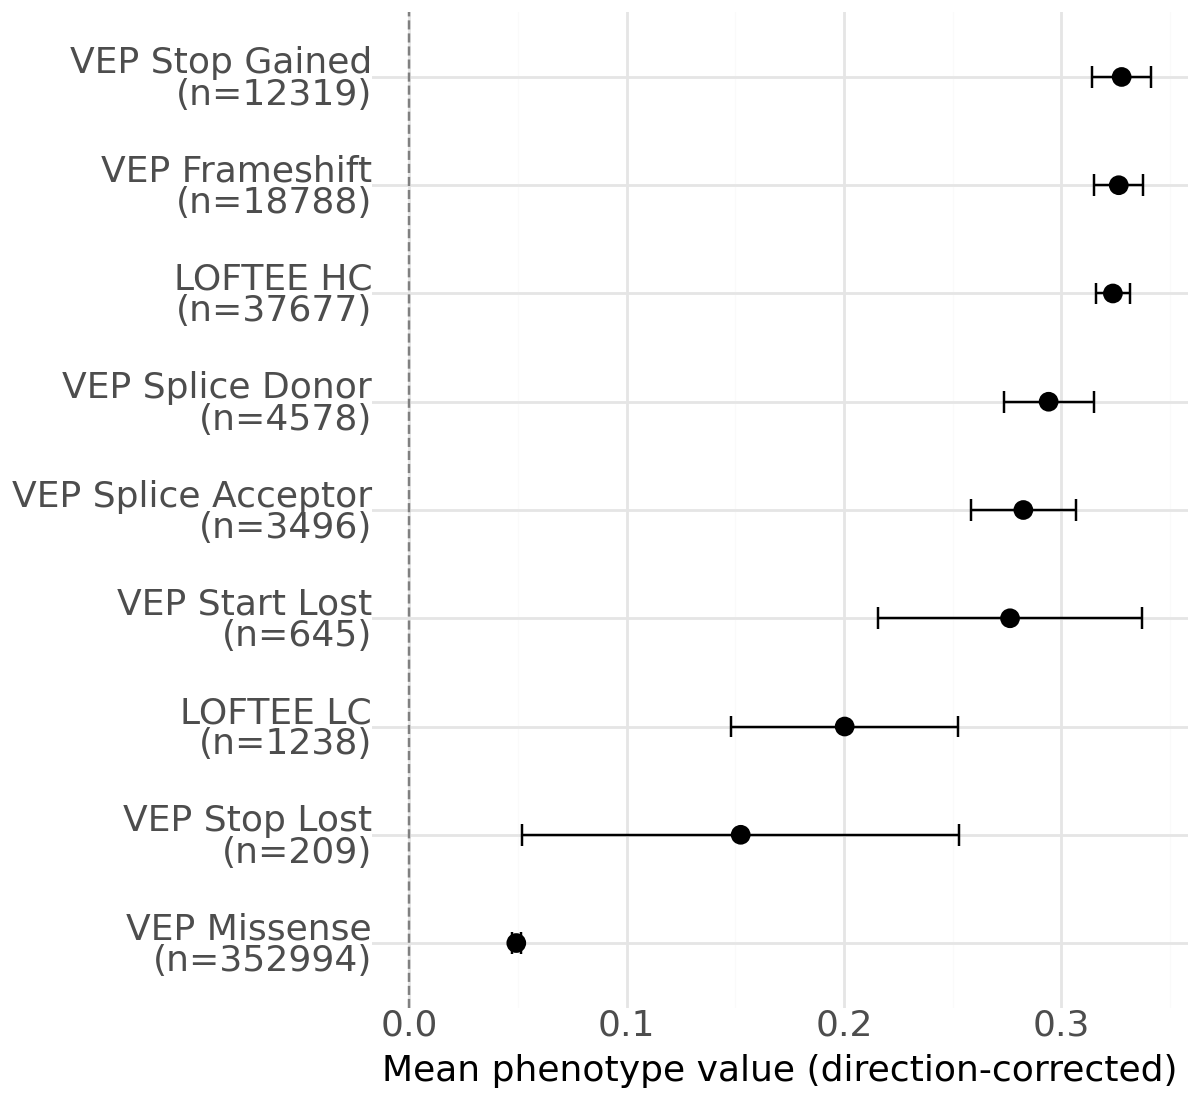

In [8]:
avg_plof_plot = (
    plof_pheno_df
    .join(
        anno_config_df.drop('category').unique(), 
        on='annotation'
    )
    .to_pandas()
)

avg_plof_plot['n_label'] = avg_plof_plot['label'] + '\n(n=' + avg_plof_plot['n_vars'].astype(str) + ')'

avg_plof_plot['n_label'] = pd.Categorical(
    avg_plof_plot['n_label'],
    categories=avg_plof_plot.sort_values('mean_pheno', ascending=True)['n_label'].unique(),
    ordered=True
)

(
    ggplot(
        avg_plof_plot,
        aes(x='n_label', y='mean_pheno')
    )
    + geom_hline(yintercept=0, linetype='dashed', color='grey')
    + geom_point(size=3)
    + geom_errorbar(
        aes(ymin='ci_low_pheno', ymax='ci_high_pheno'),
        width=0.2,
    )
    + labs(
        x='', 
        y='Mean phenotype value (direction-corrected)'
    )
    + coord_flip()
    + theme_minimal()
    + theme(
        figure_size=(6, 5.5),
        axis_text=element_text(size=13),
        axis_title=element_text(size=13),
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
        plot_background=element_rect(fill="white", color="white"),
    )
)

## Genome-wide scores

In [9]:
# Load annotation configuration
config_path = "/home/dnanexus/ukbgym/config_odds.yaml"
with open(config_path) as f:
    config = yaml.safe_load(f)

records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
gnomw_anno_config_df = pl.DataFrame(records).with_columns(
    pl.col("annotation_dir").cast(pl.Int8)
)

gnomw_anno_config_df

category,annotation,color,label,annotation_dir
str,str,str,str,i8
"""missense""","""am_pathogenicity""","""#FFCA28""","""AlphaMissense""",1
"""missense""","""esmscoremissense""","""#FB8C00""","""ESM1v""",-1
"""missense""","""score_pai3d""","""#D84315""","""PrimateAI-3D""",1
"""genetic_diversity""","""cadd_raw""","""#1f77b4""","""CADD Raw""",1
"""conservation""","""gpn_score""","""pink""","""GPN-MSA""",-1
…,…,…,…,…
"""splicing""","""absplice_dna_max""","""#00838F""","""AbSplice (max)""",1
"""splicing""","""absplice2_max""","""#26C6DA""","""AbSplice2 (max)""",1
"""regulatory_nondir""","""promoterai_abs""","""#00A99D""","""PromoterAI abs""",-1


In [10]:
gnomw_anno = pl.scan_parquet("/home/dnanexus/data_dir/annotations_fillna_ukbgym.parquet")

plof_annos = avg_plof_plot['annotation'].to_list()
# selected_annos = ['gpn_star_llr_calibrated_mean', 'cadd_raw', 'verphylop'] #, 'abexp_abs_max']
selected_annos = ['gpn_score', 'cadd_raw', 'verphylop'] #, 'abexp_abs_max']

gnomw_anno = (
    gnomw_anno
    .filter(
        # Choose CDS
        (pl.col('vep_cds_relaxed')==True) &
        # ((pl.col('vep_cds') == True) | (pl.col('mane_cds') == True) | (pl.col('non_mane_cds') == True)) &

        # Only SNPs
        (pl.col('ref').str.len_chars()==1) & (pl.col('alt').str.len_chars()==1)
    )
    .select(
        set(['id', 'region', 'gene_name'])
        .union(set(selected_annos))
        .union(set(plof_annos))
    )
    .collect(engine='streaming')

    .unpivot(
        index=set(['id', 'region', 'gene_name']).union(plof_annos),
        on=selected_annos,
        variable_name='annotation',
        value_name='annotation_score',
    )
    .unpivot(
        index = ['id', 'region', 'gene_name', 'annotation', 'annotation_score'],
        variable_name='plof_type',
        value_name='plof_score',
    )
    .filter(
        pl.col('plof_score') == 1
    )
    .join(
        gnomw_anno_config_df.drop('category').unique(), 
        on='annotation'
    )
    .join(
        anno_config_df.rename({
            'annotation':'plof_type', 
            'annotation_dir':'plof_dir',
            'label':'label_plof'
        }).select(['plof_type', 'plof_dir', 'label_plof']).unique(),
        on='plof_type'
    )
    .with_columns(
        annotation_score_dircorr = (pl.col("annotation_score")*pl.col("annotation_dir")).cast(pl.Float32),
    )
)

gnomw_anno


id,region,gene_name,annotation,annotation_score,plof_type,plof_score,color,label,annotation_dir,plof_dir,label_plof,annotation_score_dircorr
str,str,str,str,f32,str,i8,str,str,i8,i8,str,f32
"""chr1:177933615:G:A""","""ENSG00000120341""","""SEC16B""","""gpn_score""",-1.6,"""consequence_stop_gained""",1,"""pink""","""GPN-MSA""",-1,1,"""VEP Stop Gained""",1.6
"""chr10:87965446:C:T""","""ENSG00000171862""","""PTEN""","""gpn_score""",-11.58,"""consequence_stop_gained""",1,"""pink""","""GPN-MSA""",-1,1,"""VEP Stop Gained""",11.58
"""chr2:178571794:G:A""","""ENSG00000155657""","""TTN""","""gpn_score""",-8.21,"""consequence_stop_gained""",1,"""pink""","""GPN-MSA""",-1,1,"""VEP Stop Gained""",8.21
"""chr6:43225823:A:T""","""ENSG00000112667""","""DNPH1""","""gpn_score""",-6.78,"""consequence_stop_gained""",1,"""pink""","""GPN-MSA""",-1,1,"""VEP Stop Gained""",6.78
"""chr19:39173666:C:T""","""ENSG00000130669""","""PAK4""","""gpn_score""",-4.05,"""consequence_stop_gained""",1,"""pink""","""GPN-MSA""",-1,1,"""VEP Stop Gained""",4.05
…,…,…,…,…,…,…,…,…,…,…,…,…
"""chr13:113119006:T:A""","""ENSG00000057593""","""F7""","""verphylop""",1.185,"""consequence_stop_lost""",1,"""#483D8B""","""Vertebrate PhyloP""",1,1,"""VEP Stop Lost""",1.185
"""chr15:88874479:T:C""","""ENSG00000157766""","""ACAN""","""verphylop""",1.901,"""consequence_stop_lost""",1,"""#483D8B""","""Vertebrate PhyloP""",1,1,"""VEP Stop Lost""",1.901
"""chr10:79614112:G:C""","""ENSG00000122852""","""SFTPA1""","""verphylop""",0.878,"""consequence_stop_lost""",1,"""#483D8B""","""Vertebrate PhyloP""",1,1,"""VEP Stop Lost""",0.878


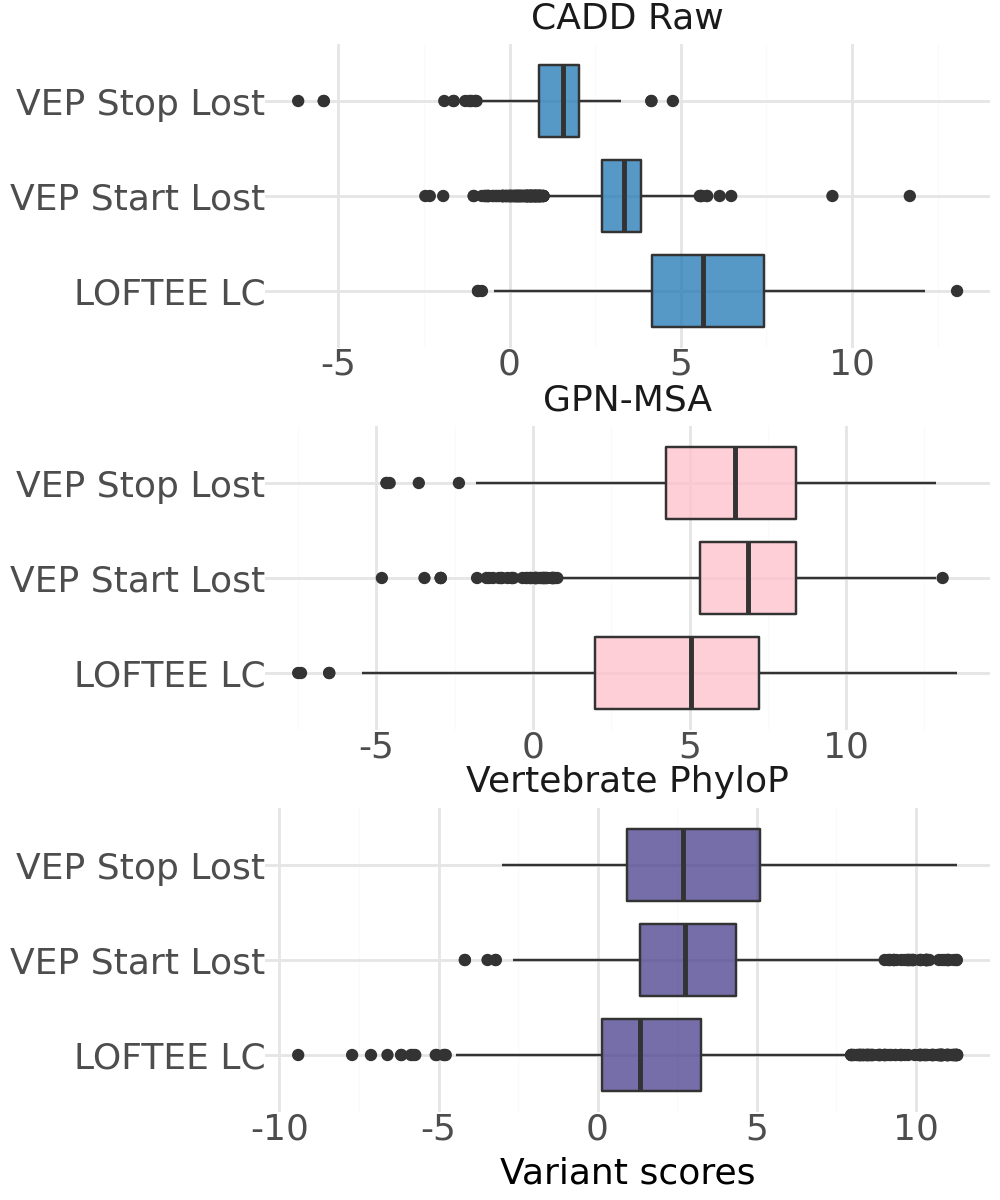

In [11]:
gnomw_anno_plot = gnomw_anno.filter(
    pl.col('plof_type').is_in(['loftee_lc', 'consequence_stop_lost', 'consequence_start_lost'])
)

color_dict = dict(zip(gnomw_anno_config_df['label'], gnomw_anno_config_df['color']))

(
    ggplot(
        gnomw_anno_plot,
        aes(y='annotation_score_dircorr', x='label_plof', fill='label')
    )
    + geom_boxplot(width=0.75, alpha=0.75)
    + facet_wrap('~label', scales='free_x', nrow=3)
    + scale_fill_manual(values=color_dict)
    + labs(
        x='',
        y='Variant scores'
    )
    + theme_minimal()
    + coord_flip()
    + theme(
        figure_size=(5, 6),
        legend_position='none',
        axis_text=element_text(size=13),
        axis_title=element_text(size=13),
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
        strip_text=element_text(size=13),
        plot_background=element_rect(fill="white", color="white"),
    )
)